### **Autor:** David Roca Tauste
---

# CARGA Y PREPROCESAMIENTO DE DATOS

In [337]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import re
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    Dense,
    Dropout,
    GRU,
)

In [338]:
nombres_columnas = "Class Index", "Title", "Description"
df = pd.read_csv("train.csv", names=nombres_columnas)

df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [339]:
df["Title"] = df["Title"] + df["Description"]
df = df.drop("Description", axis=1)

df.head()

,Class Index,Title
0,3,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new..."


In [340]:
df["Class Index"] = df["Class Index"].replace([1, 2, 3, 4], ["World", "Sports", "Business", "Sci/Tech"])
df.head()

,Class Index,Title
0,Business,Wall St. Bears Claw Back Into the Black (Reute...
1,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Business,Iraq Halts Oil Exports from Main Southern Pipe...
4,Business,"Oil prices soar to all-time record, posing new..."


In [341]:
df = df.sample(n=1000, random_state=42)
df.head()

,Class Index,Title
71787,Business,"BBC set for major shake-up, claims newspaperLo..."
67218,Business,Marsh averts cash crunchEmbattled insurance br...
54066,Sports,"Jeter, Yankees Look to Take Control (AP)AP - D..."
7168,Sci/Tech,Flying the Sun to SafetyWhen the Genesis capsu...
29618,Business,Stocks Seen Flat as Nortel and Oil Weigh NEW Y...


In [342]:
# Quitar puntuación
df['Title'] = df['Title'].apply(lambda x: re.sub(r"[^\w\s]", "", x))

# Letras a minúsculas
df['Title'] = df['Title'].str.lower()

df.head()

,Class Index,Title
71787,Business,bbc set for major shakeup claims newspaperlond...
67218,Business,marsh averts cash crunchembattled insurance br...
54066,Sports,jeter yankees look to take control apap derek...
7168,Sci/Tech,flying the sun to safetywhen the genesis capsu...
29618,Business,stocks seen flat as nortel and oil weigh new y...


In [343]:
N = 15000
T = 50

vectorizer = TextVectorization(max_tokens=N, output_sequence_length=T)
vectorizer.adapt(df['Title'].values)

In [344]:
columnas_one_hot = pd.get_dummies(df["Class Index"], columns=["Class Index"], prefix='Class')

df = df.join(columnas_one_hot)
df = df.drop("Class Index", axis=1)

df.head()

,Title,Class_Business,Class_Sci/Tech,Class_Sports,Class_World
71787,bbc set for major shakeup claims newspaperlond...,True,False,False,False
67218,marsh averts cash crunchembattled insurance br...,True,False,False,False
54066,jeter yankees look to take control apap derek...,False,False,True,False
7168,flying the sun to safetywhen the genesis capsu...,False,True,False,False
29618,stocks seen flat as nortel and oil weigh new y...,True,False,False,False


In [345]:
X = vectorizer(df['Title'].values)
y = columnas_one_hot

X_train, X_val, y_train, y_val = train_test_split(X.numpy(), y, test_size=0.2, random_state=42)

---
# MODELO GRU CON EMBEDDINGS

In [346]:
numero_clases = len(y.columns)

In [347]:
model = Sequential([
    Embedding(input_dim=N, output_dim=64),
    GRU(units=64, return_sequences=True),
    GRU(units=32),
    Dropout(0.3),
    Dense(numero_clases, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [348]:
history = model.fit(X_train, y_train, epochs=8, batch_size=64, validation_data=(X_val, y_val))

Epoch 1/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.2749 - loss: 1.3852 - val_accuracy: 0.2900 - val_loss: 1.3828
Epoch 2/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.2737 - loss: 1.3835 - val_accuracy: 0.2950 - val_loss: 1.3867
Epoch 3/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.3028 - loss: 1.3806 - val_accuracy: 0.2350 - val_loss: 1.3904
Epoch 4/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3250 - loss: 1.3797 - val_accuracy: 0.2400 - val_loss: 1.3865
Epoch 5/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3443 - loss: 1.3737 - val_accuracy: 0.2900 - val_loss: 1.3854
Epoch 6/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3261 - loss: 1.3689 - val_accuracy: 0.2700 - val_loss: 1.3812
Epoch 7/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4115 - loss: 1.3219 - val_accuracy: 0.4300 - val_loss: 1.2234
Epoch 8/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5613 - loss: 0.9623 - val_accuracy: 0.5600 - val_loss:

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5300 - loss: 1.0087
Precisión en validación: 0.5600


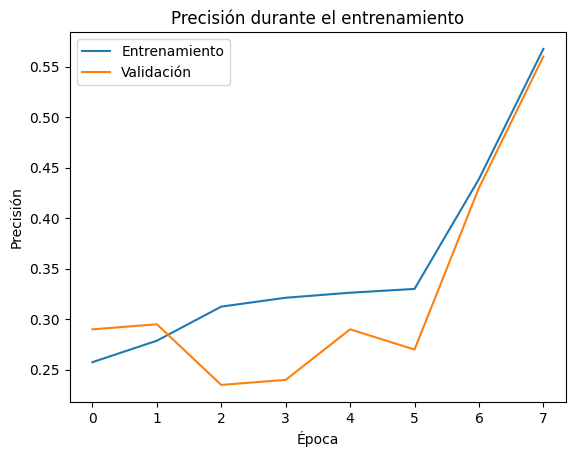

In [349]:
# Evaluar
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Precisión en validación: {accuracy:.4f}")

# Curva de precisión
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento')
plt.show()

Como podemos observar, el modelo ha obtenido las siguientes métricas:
- accuracy: 0.5067
- loss: 1.2663
- Precisión en validación: 0.4900

In [350]:
# Almacenar en formato serializado 
joblib.dump(model, 'modelo_entrenado.pkl')
joblib.dump(vectorizer, 'vectorizador.pkl')

['vectorizador.pkl']